In [6]:
# PROJECT 2: Customer Churn Cohort Analysis
# Visualizations from SQL findings

!pip install kaggle -q

import os, json

kaggle_credentials = {
    "username": "cynthiawanjiku",
    "key": "KGAT_8230434584795821c21884683601bd65"
}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d blastchar/telco-customer-churn --unzip -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['Churn'] = df['Churn'].str.strip()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

print(f"✅ Dataset loaded — {df.shape[0]:,} rows")
print(f"📊 Churn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")
print(f"👥 Churned customers: {(df['Churn']=='Yes').sum():,}")

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
✅ Dataset loaded — 7,043 rows
📊 Churn rate: 26.54%
👥 Churned customers: 1,869


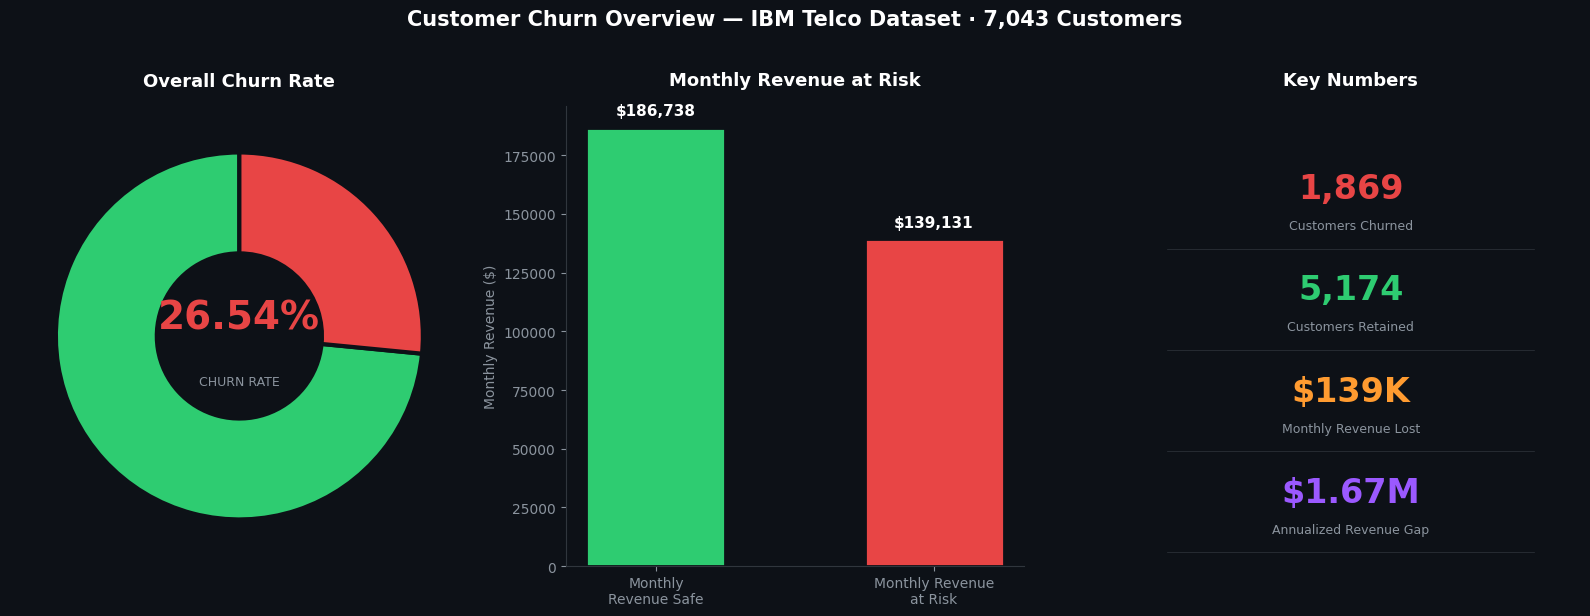

✅ Chart 1 saved


In [7]:
# ============================================================
# CHART 1: Overall Churn Overview — KPI Summary Visual
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# --- Donut chart ---
ax1 = axes[0]
ax1.set_facecolor('#0D1117')
sizes = [73.46, 26.54]
colors = ['#2ECC71', '#E84545']
wedges, texts = ax1.pie(sizes, colors=colors, startangle=90,
                         wedgeprops=dict(width=0.55, edgecolor='#0D1117', linewidth=3))
ax1.text(0, 0.1, '26.54%', ha='center', va='center',
         fontsize=28, fontweight='bold', color='#E84545')
ax1.text(0, -0.25, 'CHURN RATE', ha='center', va='center',
         fontsize=9, color='#8B949E')
ax1.set_title('Overall Churn Rate', fontsize=13, fontweight='bold',
              color='white', pad=15)

# --- Revenue at risk bar ---
ax2 = axes[1]
ax2.set_facecolor('#0D1117')
categories = ['Monthly\nRevenue Safe', 'Monthly Revenue\nat Risk']
values = [325869 - 139131, 139131]
bar_colors = ['#2ECC71', '#E84545']
bars = ax2.bar(categories, values, color=bar_colors, width=0.5,
               edgecolor='#0D1117', linewidth=2)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 4000,
             f'${val:,.0f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='white')
ax2.set_facecolor('#0D1117')
ax2.tick_params(colors='#8B949E')
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_ylabel('Monthly Revenue ($)', color='#8B949E', fontsize=10)
ax2.set_title('Monthly Revenue at Risk', fontsize=13, fontweight='bold', color='white', pad=15)
ax2.yaxis.label.set_color('#8B949E')
ax2.tick_params(axis='both', colors='#8B949E')

# --- Key numbers ---
ax3 = axes[2]
ax3.set_facecolor('#161B22')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')
kpis = [
    ('1,869', 'Customers Churned', '#E84545'),
    ('5,174', 'Customers Retained', '#2ECC71'),
    ('$139K', 'Monthly Revenue Lost', '#FF9B30'),
    ('$1.67M', 'Annualized Revenue Gap', '#9B59FF'),
]
for i, (num, label, color) in enumerate(kpis):
    y = 0.82 - i * 0.22
    ax3.text(0.5, y, num, ha='center', va='center',
             fontsize=24, fontweight='bold', color=color)
    ax3.text(0.5, y - 0.08, label, ha='center', va='center',
             fontsize=9, color='#8B949E')
    ax3.axhline(y=y - 0.13, xmin=0.1, xmax=0.9,
                color='#30363D', linewidth=0.5)
ax3.set_title('Key Numbers', fontsize=13, fontweight='bold', color='white', pad=15)
ax3.title.set_position([0.5, 1.02])

fig.suptitle('Customer Churn Overview — IBM Telco Dataset · 7,043 Customers',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('chart_01_churn_overview.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("✅ Chart 1 saved")


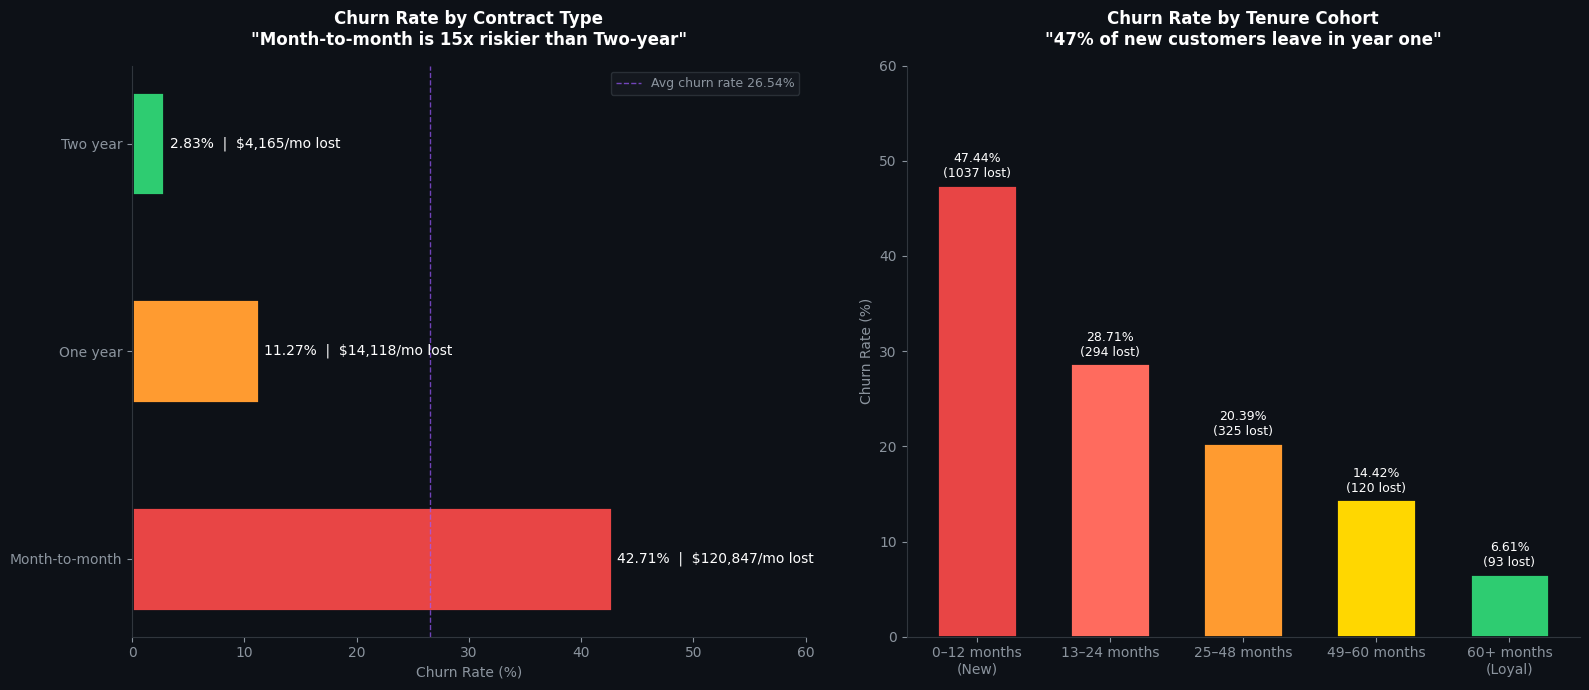

✅ Chart 2 saved


In [8]:
# ============================================================
# CHART 2: Churn by Contract Type & Tenure Cohort
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0D1117')

# --- Contract type ---
ax1.set_facecolor('#0D1117')
contracts = ['Month-to-month', 'One year', 'Two year']
churn_rates = [42.71, 11.27, 2.83]
revenue_lost = [120847, 14118, 4165]
bar_colors = ['#E84545', '#FF9B30', '#2ECC71']

bars = ax1.barh(contracts, churn_rates, color=bar_colors,
                height=0.5, edgecolor='#0D1117', linewidth=2)
for bar, rate, rev in zip(bars, churn_rates, revenue_lost):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{rate}%  |  ${rev:,.0f}/mo lost',
             va='center', fontsize=10, color='white', fontweight='500')
ax1.set_xlim(0, 60)
ax1.set_xlabel('Churn Rate (%)', color='#8B949E', fontsize=10)
ax1.set_title('Churn Rate by Contract Type\n"Month-to-month is 15x riskier than Two-year"',
              fontsize=12, fontweight='bold', color='white', pad=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.tick_params(colors='#8B949E')
ax1.axvline(x=26.54, color='#9B59FF', linestyle='--',
            linewidth=1, alpha=0.7, label='Avg churn rate 26.54%')
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='#8B949E',
           edgecolor='#30363D')

# --- Tenure cohort ---
ax2.set_facecolor('#0D1117')
bands = ['0–12 months\n(New)', '13–24 months', '25–48 months',
         '49–60 months', '60+ months\n(Loyal)']
rates = [47.44, 28.71, 20.39, 14.42, 6.61]
churned = [1037, 294, 325, 120, 93]

colors_grad = ['#E84545', '#FF6B5E', '#FF9B30', '#FFD700', '#2ECC71']
bars2 = ax2.bar(bands, rates, color=colors_grad, width=0.6,
                edgecolor='#0D1117', linewidth=2)

for bar, rate, ch in zip(bars2, rates, churned):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{rate}%\n({ch} lost)', ha='center', va='bottom',
             fontsize=9, color='white', fontweight='500')

ax2.set_ylabel('Churn Rate (%)', color='#8B949E', fontsize=10)
ax2.set_title('Churn Rate by Tenure Cohort\n"47% of new customers leave in year one"',
              fontsize=12, fontweight='bold', color='white', pad=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.tick_params(colors='#8B949E', axis='both')
ax2.set_ylim(0, 60)

fig.patch.set_facecolor('#0D1117')
plt.tight_layout()
plt.savefig('chart_02_contract_tenure.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("✅ Chart 2 saved")

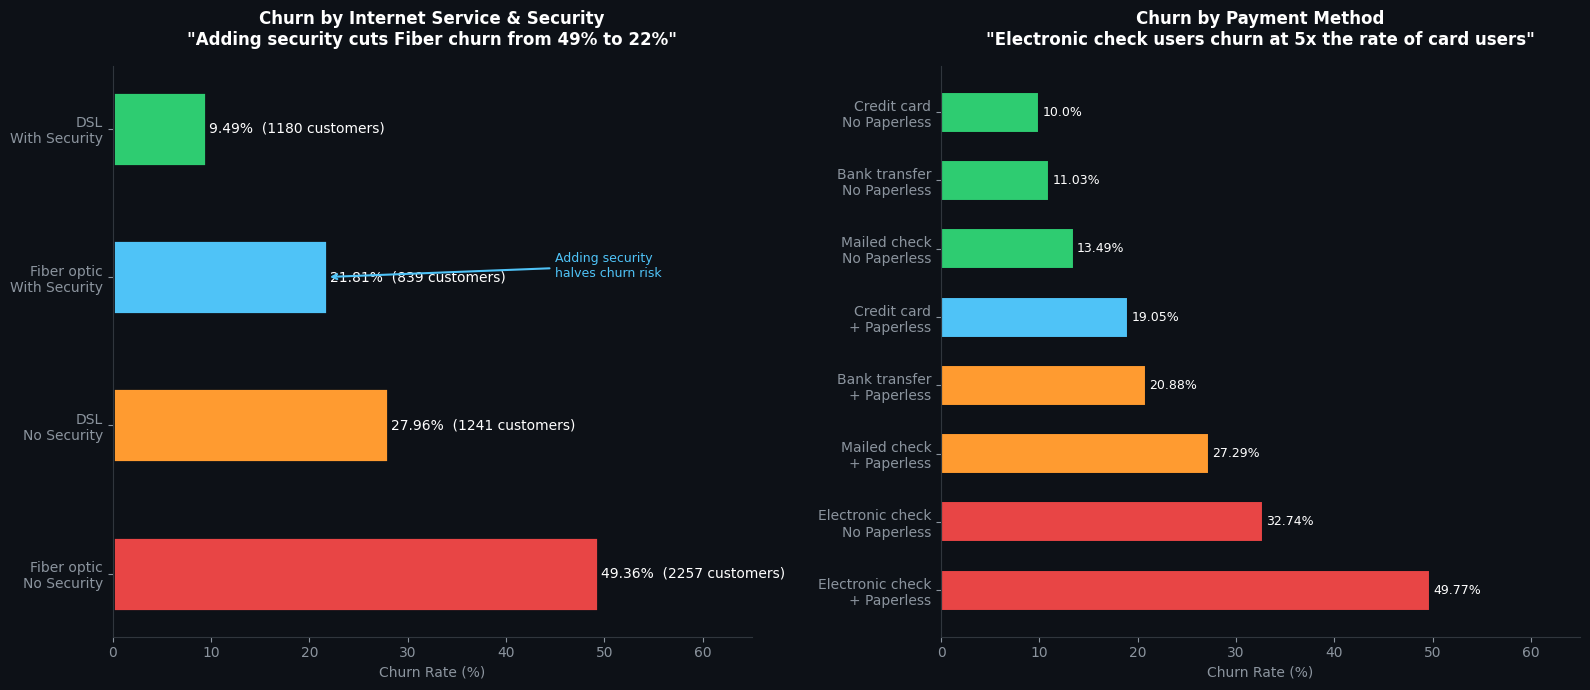

✅ Chart 3 saved


In [9]:
# ============================================================
# CHART 3: Internet Service + Security & Payment Method
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0D1117')

# --- Internet + Security ---
ax1.set_facecolor('#0D1117')
categories = ['Fiber optic\nNo Security', 'DSL\nNo Security',
              'Fiber optic\nWith Security', 'DSL\nWith Security']
rates = [49.36, 27.96, 21.81, 9.49]
customers = [2257, 1241, 839, 1180]
colors_is = ['#E84545', '#FF9B30', '#4FC3F7', '#2ECC71']

bars = ax1.barh(categories, rates, color=colors_is,
                height=0.5, edgecolor='#0D1117', linewidth=2)
for bar, rate, cust in zip(bars, rates, customers):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{rate}%  ({cust} customers)',
             va='center', fontsize=10, color='white')

ax1.set_xlim(0, 65)
ax1.set_xlabel('Churn Rate (%)', color='#8B949E', fontsize=10)
ax1.set_title('Churn by Internet Service & Security\n"Adding security cuts Fiber churn from 49% to 22%"',
              fontsize=12, fontweight='bold', color='white', pad=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.tick_params(colors='#8B949E')

# Add annotation arrow
ax1.annotate('Adding security\nhalves churn risk',
             xy=(21.81, 2), xytext=(45, 2),
             fontsize=9, color='#4FC3F7',
             arrowprops=dict(arrowstyle='->', color='#4FC3F7', lw=1.5))

# --- Payment method ---
ax2.set_facecolor('#0D1117')
payments = ['Electronic check\n+ Paperless', 'Electronic check\nNo Paperless',
            'Mailed check\n+ Paperless', 'Bank transfer\n+ Paperless',
            'Credit card\n+ Paperless', 'Mailed check\nNo Paperless',
            'Bank transfer\nNo Paperless', 'Credit card\nNo Paperless']
pay_rates = [49.77, 32.74, 27.29, 20.88, 19.05, 13.49, 11.03, 10.00]
pay_colors = ['#E84545' if r > 30 else '#FF9B30' if r > 20
              else '#4FC3F7' if r > 15 else '#2ECC71'
              for r in pay_rates]

bars2 = ax2.barh(payments, pay_rates, color=pay_colors,
                 height=0.6, edgecolor='#0D1117', linewidth=1.5)
for bar, rate in zip(bars2, pay_rates):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{rate}%', va='center', fontsize=9, color='white')

ax2.set_xlim(0, 65)
ax2.set_xlabel('Churn Rate (%)', color='#8B949E', fontsize=10)
ax2.set_title('Churn by Payment Method\n"Electronic check users churn at 5x the rate of card users"',
              fontsize=12, fontweight='bold', color='white', pad=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.tick_params(colors='#8B949E')

plt.tight_layout()
plt.savefig('chart_03_internet_payment.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("✅ Chart 3 saved")

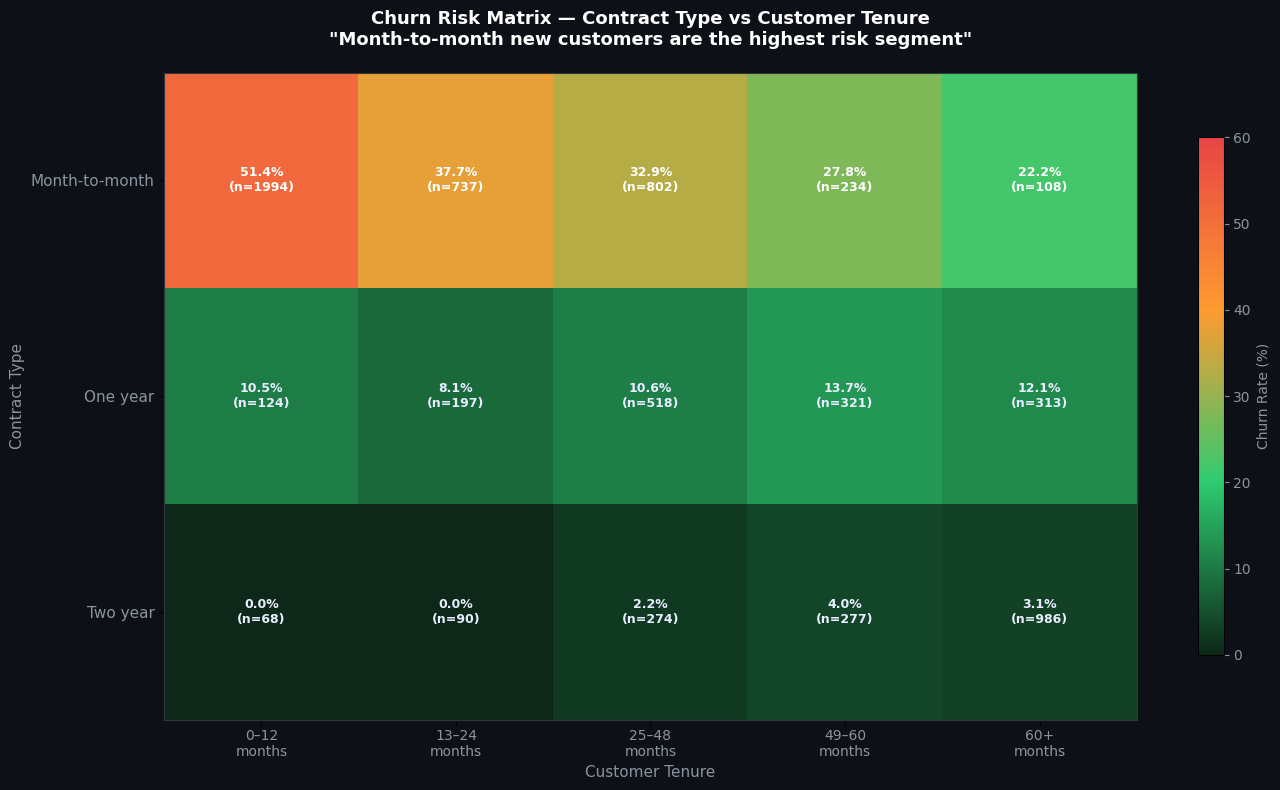

✅ Chart 4 saved


In [10]:
# ============================================================
# CHART 4: Churn Risk Matrix — Contract vs Tenure
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

contract_types = ['Month-to-month', 'One year', 'Two year']
tenure_bands = ['0–12\nmonths', '13–24\nmonths', '25–48\nmonths',
                '49–60\nmonths', '60+\nmonths']

# Calculate churn rates for each cell
matrix_data = []
labels = []
for contract in contract_types:
    row = []
    row_labels = []
    for t_min, t_max in [(0,12),(13,24),(25,48),(49,60),(61,200)]:
        mask = (df['Contract'] == contract) & \
               (df['tenure'] >= t_min) & (df['tenure'] <= t_max)
        subset = df[mask]
        if len(subset) > 0:
            rate = (subset['Churn'] == 'Yes').sum() / len(subset) * 100
            count = len(subset)
        else:
            rate = 0
            count = 0
        row.append(rate)
        row_labels.append(f'{rate:.1f}%\n(n={count})')
    matrix_data.append(row)
    labels.append(row_labels)

matrix = np.array(matrix_data)

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list(
    'churn', ['#0D2818', '#2ECC71', '#FF9B30', '#E84545'])

im = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=0, vmax=60)

ax.set_xticks(range(len(tenure_bands)))
ax.set_xticklabels(tenure_bands, color='#8B949E', fontsize=10)
ax.set_yticks(range(len(contract_types)))
ax.set_yticklabels(contract_types, color='#8B949E', fontsize=11)

for i in range(len(contract_types)):
    for j in range(len(tenure_bands)):
        rate = matrix[i, j]
        label = labels[i][j]
        text_color = 'white' if rate > 20 else '#E8EEFF'
        ax.text(j, i, label, ha='center', va='center',
                color=text_color, fontsize=9, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Churn Rate (%)', color='#8B949E', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='#8B949E')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8B949E')

ax.set_title('Churn Risk Matrix — Contract Type vs Customer Tenure\n'
             '"Month-to-month new customers are the highest risk segment"',
             fontsize=13, fontweight='bold', color='white', pad=20)
ax.set_xlabel('Customer Tenure', color='#8B949E', fontsize=11)
ax.set_ylabel('Contract Type', color='#8B949E', fontsize=11)

ax.spines['bottom'].set_color('#30363D')
ax.spines['left'].set_color('#30363D')
ax.spines['top'].set_color('#30363D')
ax.spines['right'].set_color('#30363D')

plt.tight_layout()
plt.savefig('chart_04_churn_risk_matrix.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("✅ Chart 4 saved")